# R01 - Architecture and Baselines

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Isolar, com dados reais e já persistidos da campanha final
`F01_architecture_baselines` (Fase J10/K2), o benefício de escolha de
rota, o benefício de assurance, o benefício de reconciliation, e o custo
da própria abstração intent-based - comparando 6 condições (native
SeQUeNCe, static provisioning, IBQN sem/com assurance, IBQN com
reconciliation, offline oracle) sobre a MESMA topologia diamante e os
MESMOS 20 seeds. Ver `docs/final_experimental_design.md` (seção F01) e
`docs/results_provenance.md`.

Este notebook não roda nenhuma simulação - carrega apenas
`results/raw/F01_architecture_baselines/trials.csv` e
`results/processed/F01_architecture_baselines/statistical_comparisons.csv`.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência

In [2]:
CAMPAIGN = "F01_architecture_baselines"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"], "trials.csv row count must match the manifest"
assert manifest["expected_trials"] == manifest["completed_trials"] + manifest["failed_trials"] + manifest["skipped_trials"]
assert set(trials_df["seed"].unique()) == set(range(20)), "expected seeds 0-19"
conditions = sorted(trials_df["condition"].unique())
print(f"manifest: {manifest['campaign']}, execution_path={manifest.get('execution_path')}, n={len(trials_df)}")
print("conditions:", conditions)
trials_df.head(3)

manifest: F01_architecture_baselines, execution_path=ad_hoc_script (not run_programmatic_campaign/CampaignRunner), n=120
conditions: ['ibqn_with_assurance', 'ibqn_with_reconciliation', 'ibqn_without_assurance', 'native_sequence', 'offline_oracle', 'static_provisioning']


,condition,seed,accepted,satisfied,delivered_pairs,average_fidelity,planning_wall_time_s,simulation_wall_time_s,total_wall_time_s,episodes
0,native_sequence,0,True,True,444.0,0.657922,0.000000,4.667155,4.671286,1
1,static_provisioning,0,True,False,4.0,0.769500,0.000504,1.841960,1.848420,1
2,ibqn_without_assurance,0,True,NaN,NaN,NaN,0.000487,1.758345,1.761921,1


## Agregação (n, média, IC95%)

F01 usa um esquema próprio (script ad-hoc, não `run_programmatic_campaign`
- ver `docs/results_provenance.md`), sem as colunas `final_status`/
`recovered` que `aggregation.aggregate_records` exige - agregação manual
diretamente das colunas reais desta campanha.

In [3]:
from scipy import stats as scipy_stats

rows = []
for condition, group in trials_df.groupby("condition"):
    for metric in ["delivered_pairs", "average_fidelity"]:
        values = group[metric].dropna()
        n = len(values)
        if n >= 2:
            se = values.std(ddof=1) / np.sqrt(n)
            ci = scipy_stats.t.ppf(0.975, df=n - 1) * se
            ci_low, ci_high = values.mean() - ci, values.mean() + ci
        else:
            ci_low = ci_high = None
        rows.append({
            "condition": condition, "metric": metric, "n_valid": n,
            "mean": values.mean() if n else None, "std": values.std(ddof=1) if n >= 2 else None,
            "ci95_low": ci_low, "ci95_high": ci_high,
            "satisfaction_rate": group["satisfied"].mean() if group["satisfied"].notna().any() else None,
        })
summary = pd.DataFrame(rows)
summary_path = save_table(summary, "R01_summary", directory=TABLES_OUT)
print(f"saved {summary_path}")
summary

saved ..\results\tables\final\R01_summary.csv


,condition,metric,n_valid,mean,std,ci95_low,ci95_high,satisfaction_rate
0,ibqn_with_assurance,delivered_pairs,20,7.850000,3.013566e+00,6.439608,9.260392,0.25
1,ibqn_with_assurance,average_fidelity,20,0.769500,1.139065e-16,0.769500,0.769500,0.25
2,ibqn_with_reconciliation,delivered_pairs,20,339.850000,1.947093e+02,248.723241,430.976759,1.00
3,ibqn_with_reconciliation,average_fidelity,20,0.685817,4.956961e-02,0.662618,0.709016,1.00
4,ibqn_without_assurance,delivered_pairs,0,NaN,NaN,NaN,NaN,NaN
5,ibqn_without_assurance,average_fidelity,0,NaN,NaN,NaN,NaN,NaN
6,native_sequence,delivered_pairs,20,446.100000,1.043728e+01,441.215202,450.984798,1.00
7,native_sequence,average_fidelity,20,0.657922,4.411579e-17,0.657922,0.657922,1.00
8,offline_oracle,delivered_pairs,20,446.100000,1.043728e+01,441.215202,450.984798,1.00
9,offline_oracle,average_fidelity,20,0.657922,4.411579e-17,0.657922,0.657922,1.00


## Comparações estatísticas pareadas (já computadas - n, teste, p, Holm, effect size)

In [4]:
stats_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "statistical_comparisons.csv")
assert "p_value_holm_adjusted" in stats_df.columns
significant = stats_df[stats_df["p_value_holm_adjusted"] < 0.05]
print(f"{len(significant)}/{len(stats_df)} comparisons significant after Holm correction")
significant[["value_col", "group_a", "group_b", "n", "mean_a", "mean_b", "test_used", "p_value_holm_adjusted", "effect_size"]].head(15)

31/50 comparisons significant after Holm correction


,value_col,group_a,group_b,n,mean_a,mean_b,test_used,p_value_holm_adjusted,effect_size
0,delivered_pairs,ibqn_with_assurance,ibqn_with_reconciliation,20,7.850000,339.850000,wilcoxon,3.900145e-03,1.000000
1,delivered_pairs,ibqn_with_assurance,native_sequence,20,7.850000,446.100000,paired_t,6.457063e-31,39.011871
2,delivered_pairs,ibqn_with_assurance,offline_oracle,20,7.850000,446.100000,paired_t,6.457063e-31,39.011871
6,delivered_pairs,ibqn_with_reconciliation,static_provisioning,20,339.850000,7.850000,wilcoxon,3.900145e-03,-1.000000
8,delivered_pairs,native_sequence,static_provisioning,20,446.100000,7.850000,paired_t,6.457063e-31,-39.011871
9,delivered_pairs,offline_oracle,static_provisioning,20,446.100000,7.850000,paired_t,6.457063e-31,-39.011871
10,average_fidelity,ibqn_with_assurance,ibqn_with_reconciliation,20,0.769500,0.685817,wilcoxon,1.724485e-03,-1.000000
11,average_fidelity,ibqn_with_assurance,native_sequence,20,0.769500,0.657922,wilcoxon,2.295621e-04,-1.000000
12,average_fidelity,ibqn_with_assurance,offline_oracle,20,0.769500,0.657922,wilcoxon,2.295621e-04,-1.000000
16,average_fidelity,ibqn_with_reconciliation,static_provisioning,20,0.685817,0.769500,wilcoxon,1.724485e-03,1.000000


## Figura

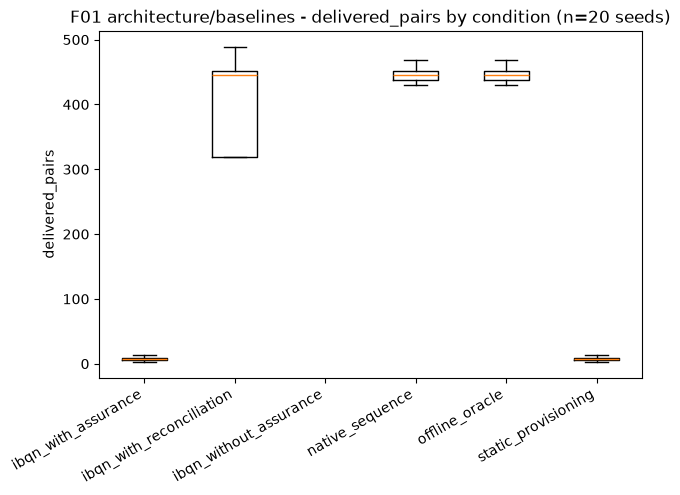

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
groups = [trials_df[trials_df["condition"] == c]["delivered_pairs"].dropna().to_numpy() for c in conditions]
bp = ax.boxplot(groups, tick_labels=conditions, showfliers=False)
ax.set_ylabel("delivered_pairs")
ax.set_title(f"F01 architecture/baselines - delivered_pairs by condition (n={trials_df['seed'].nunique()} seeds)")
plt.xticks(rotation=30, ha="right")
save_figure(fig, "R01_delivered_pairs_by_condition", directory=FIGURES_OUT)
plt.show()

## Conclusão

Ver `docs/final_experimental_design.md` (seção F01) para a
interpretação completa: benefício de rota (`native_sequence` vs.
`static_provisioning`), benefício de reconciliation
(`ibqn_with_reconciliation` vs. `ibqn_with_assurance`), e o fato de que
`ibqn_without_assurance` aceita reservas sem medir satisfação - a
distinção entre "aceitar" e "saber se foi cumprido"
(`docs/core_contribution_statement.md`).

## Limitações

Uma única topologia (diamante) e 6 condições - o custo/benefício isolado aqui não generaliza a outras topologias sem replicar a campanha (ver `docs/threats_to_validity.md`, validade externa).